In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm


## Models

In [ ]:
access_token = "YOUR_ACCESS TOKEN"

#### Gemma 2

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer

model_load_name = "google/gemma-2-2b-it"

model = AutoModelForCausalLM.from_pretrained(
    model_load_name,
    torch_dtype="auto",
    device_map="auto",
    token = access_token
)
tokenizer = AutoTokenizer.from_pretrained(model_load_name,padding_side='left',token = access_token)

In [ ]:
def pipe(sentence, max_new_tokens = 25):
    messages = []
    text=[]
    for s in sentence:
        messages.append([
            {"role": "system", "content": "You are a useful chatbot assistant."},
            {"role": "user", "content": s}
        ])
        text.append(tokenizer.apply_chat_template(
            messages[-1],
            tokenize=False,
            add_generation_prompt=True
        ))
    model_inputs = tokenizer(text, return_tensors="pt",padding=True,truncation=True).to("cuda")
    generated_ids = model.generate(
        **model_inputs,
        max_new_tokens=max_new_tokens
    )
    generated_ids = [
        output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)
    ]

    response = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)
    return response

#### Qwen

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "Qwen/Qwen2.5-7B-Instruct"

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype="auto",
    device_map="auto"
)
tokenizer = AutoTokenizer.from_pretrained(model_name,padding_side='left')

In [3]:
def pipe(sentence):
    messages = []
    text=[]
    for s in sentence:
        messages.append([
            {"role": "system", "content": "You are a useful chatbot assistant."},
            {"role": "user", "content": s}
        ])
        text.append(tokenizer.apply_chat_template(
            messages[-1],
            tokenize=False,
            add_generation_prompt=True
        ))
    model_inputs = tokenizer(text, return_tensors="pt",padding=True,truncation=True).to("cuda")
    generated_ids = model.generate(
        **model_inputs,
        max_new_tokens=25    )
    generated_ids = [
        output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)
    ]

    response = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)
    return response

#### Llama

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer

model = AutoModelForCausalLM.from_pretrained(
    "meta-llama/Llama-3.2-3B-Instruct",
    torch_dtype="auto",
    device_map="auto",
    token = access_token
)
tokenizer = AutoTokenizer.from_pretrained("meta-llama/Llama-3.2-3B-Instruct",padding_side='left',token = access_token)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.pad_token_id = tokenizer.eos_token_id
model.generation_config.pad_token_id = tokenizer.pad_token_id

In [3]:
def pipe(sentence):
    messages = []
    text=[]
    for s in sentence:
        messages.append([
            {"role": "system", "content": "You are a useful chatbot assistant."},
            {"role": "user", "content": s}
        ])
        text.append(tokenizer.apply_chat_template(
            messages[-1],
            tokenize=False,
            add_generation_prompt=True
        ))
    model_inputs = tokenizer(text, return_tensors="pt",padding=True,truncation=True).to("cuda")
    generated_ids = model.generate(
        **model_inputs,
        max_new_tokens=25
    )
    generated_ids = [
        output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)
    ]

    response = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)
    return response

___

In [ ]:
model_name = "gemma-2-2b-it"
#model_name = "Llama-3.2-3B-Instruct"
#model_name = "Qwen2.5-7B-Instruct"

## Similarity and identification tasks

Prompt generating function

In [ ]:
def generate_prompt_birth_year(seq_len,names,type="sim",ymin = 800, ymax = 1999):
    people = names[np.argsort(np.random.rand(len(names)))[:seq_len]]
    ages = [np.random.randint(ymin,ymax) for _ in range(seq_len)]
    if type == "sim":
        probe_age = np.random.randint(ymin,ymax)
    elif type == "id":
        probe_age = ages[np.random.randint(len(ages))]
    else:
        raise ValueError("Type must be 'sim' or 'id'")
    correct = str(people[np.argmin([np.abs(ages[i] - probe_age) for i in range(seq_len)])])
    sentence = ""
    for s in range(seq_len):
        sentence += f"{people[s]} was born in {ages[s]}. " 
    if type == "sim":
        sentence += f"Who was born closest to {probe_age}?"
    elif type == "id":
        sentence += f"Who was born in {probe_age}?"
    else:
        raise ValueError("Type must be 'sim' or 'id'")
    sentence += " Answer with a single name. "
    return sentence,people,ages,correct



In [ ]:
names = np.array([
    "Aaron", "Abigail", "Adam", "Adrian", "Aiden", "Alice", "Amelia", "Andrew", "Anna", "Anthony",
    "Arthur", "Audrey", "Austin", "Ava", "Barbara", "Benjamin", "Blake", "Brandon", "Brian", "Brianna",
    "Cameron", "Caroline", "Catherine", "Charles", "Charlotte", "Chloe", "Christian", "Christopher", "Claire", "Clara",
    "Daniel", "David", "Diana", "Dylan", "Edward", "Eleanor", "Elena", "Elizabeth", "Ella", "Emily",
    "Emma", "Ethan", "Evan", "Evelyn", "Faith", "Fiona", "Frank", "Gabriel", "Grace", "Hannah",
    "Harper", "Henry", "Isabella", "Isaac", "Jack", "Jacob", "James", "Jasmine", "Jason", "Jessica",
    "John", "Jonathan", "Joseph", "Joshua", "Julia", "Katherine", "Kevin", "Liam", "Lillian", "Lily",
    "Logan", "Lucas", "Lucy", "Madeline", "Madison", "Maria", "Mason", "Matthew", "Megan", "Michael",
    "Mia", "Nathan", "Nicholas", "Noah", "Olivia", "Oscar", "Patrick", "Penelope", "Rachel", "Rebecca",
    "Ryan", "Samuel", "Sarah", "Sophia", "Thomas", "Victoria", "William", "Zachary", "Alex", "Alexa",
    "Alexander", "Alexandra", "Allison", "Amber", "Andrea", "Angela", "Ashley", "Brenda", "Brittany", "Brooke",
    "Caleb", "Cassandra", "Chelsea", "Christina", "Cindy", "Colin", "Connor", "Courtney", "Crystal", "Dakota",
    "Danielle", "Derek", "Dominic", "Donna", "Dustin", "Erica", "Erin", "Evan", "Gabriella", "Garrett",
    "Gavin", "George", "Hailey", "Heather", "Ian", "Isabelle", "Jared", "Jenna", "Jeremy", "Jillian",
    "Jordan", "Justin", "Kaitlyn", "Karen", "Kayla", "Kelly", "Kimberly", "Kristen", "Kyle", "Laura",
    "Lauren", "Leah", "Lindsay", "Logan", "Mackenzie", "Madelyn", "Makayla", "Mariah", "Marissa", "Melanie",
    "Melissa", "Michelle", "Morgan", "Natalie", "Nathaniel", "Nicole", "Paige", "Parker", "Peter", "Peyton",
    "Raymond", "Riley", "Robert", "Samantha", "Savannah", "Sean", "Shannon", "Sophia", "Spencer", "Stephanie",
    "Steven", "Sydney", "Taylor", "Tiffany", "Travis", "Trevor", "Tyler", "Vanessa", "Veronica", "Victor",
    "Vincent", "Wesley", "Whitney", "Wyatt", "Zoe", "Zoey"
])

#### Similarity

In [ ]:
nrep =200
nbatches = 5
test_type = "sim"
performance = []
n_nulls = []
ymin = 800
ymax = 1600
seq_lens = list(range(2,100,2))
for seq_len in tqdm(seq_lens):
    n_correct = 0
    n_incorrect = 0
    n_null = 0
    for b in range(nbatches):
        corrects = []
        sentences = []
        peoples = []
        for n in range(nrep):
            sentence,people,ages,correct = generate_prompt_birth_year(seq_len,names,type="sim",ymin = ymin, ymax = ymax)
            sentences.append(sentence)
            corrects.append(correct)
            peoples.append(people)

        outputs = pipe(sentences)

        for n in range(nrep):
            output_str = outputs[n]
            answer = [p for p in peoples[n] if p in output_str]
            if len(answer) == 0:
                answer = "NULL"
            else:
                answer = str(answer[0])

            if answer == corrects[n]:
                n_correct += 1
            elif answer in peoples[n]:
                n_incorrect += 1
            else:
                n_null += 1

        
    performance.append(n_correct/(n_correct+n_incorrect))
    n_nulls.append(n_null)

100%|██████████| 49/49 [29:16<00:00, 35.84s/it]


#### Identification

In [ ]:
nrep =200
nbatches = 5
test_type = "id"
ymin = 800
ymax = 1600
performance_id = []
n_nulls_id = []
seq_lens = list(range(2,100,2))
for seq_len in tqdm(seq_lens):
    n_correct = 0
    n_incorrect = 0
    n_null = 0
    for b in range(nbatches):
        corrects = []
        sentences = []
        peoples = []
        for n in range(nrep):
            sentence,people,ages,correct = generate_prompt_birth_year(seq_len,names,type="id",ymin = ymin, ymax = ymax)
            sentences.append(sentence)
            corrects.append(correct)
            peoples.append(people)

        outputs = pipe(sentences)

        for n in range(nrep):
            output_str = outputs[n]
            answer = [p for p in peoples[n] if p in output_str]
            if len(answer) == 0:
                answer = "NULL"
            else:
                answer = str(answer[0])

            if answer == corrects[n]:
                n_correct += 1
            elif answer in peoples[n]:
                n_incorrect += 1
            else:
                n_null += 1

        
    performance_id.append(n_correct/(n_correct+n_incorrect))
    n_nulls_id.append(n_null)

100%|██████████| 49/49 [22:40<00:00, 27.77s/it]


### Save results

In [ ]:
save_path = "YOUR_SAVE_PATH"

In [ ]:
import pickle

# Save similarity data
experiment_data = {
    "performance": performance,
    "n_nulls": n_nulls,
    "seq_lens": seq_lens,
    "test_type": test_type,
    "nrep": nrep
}

with open(save_path+f"/experiment_similarity_{model_name}_year.pkl", "wb") as f:
    pickle.dump(experiment_data, f)


# Save identification data
experiment_data = {
    "performance": performance_id,
    "n_nulls": n_nulls_id,
    "seq_lens": seq_lens,
    "test_type": test_type,
    "nrep": nrep
}

with open(save_path+f"/experiment_identification_{model_name}_year.pkl", "wb") as f:
    pickle.dump(experiment_data, f)

### Load saved results

In [ ]:
save_path = "YOUR_SAVE_PATH"

In [ ]:
model_names = ["gemma-2-2b-it","Llama-3.2-3B-Instruct","Qwen2.5-7B-Instruct"]
performances_sim = {m:[] for m in model_names}
performances_id = {m:[] for m in model_names}
for m in model_names:
    with open(save_path+f"/experiment_similarity_{m}_year.pkl", "rb") as f:
        experiment_data = pickle.load(f)
    performances_sim[m] = experiment_data["performance"]
    with open(save_path+f"/experiment_identification_{m}_year.pkl", "rb") as f:
        experiment_data = pickle.load(f)
    performances_id[m] = experiment_data["performance"]
    seq_lens = experiment_data["seq_lens"]

#### Figure 10

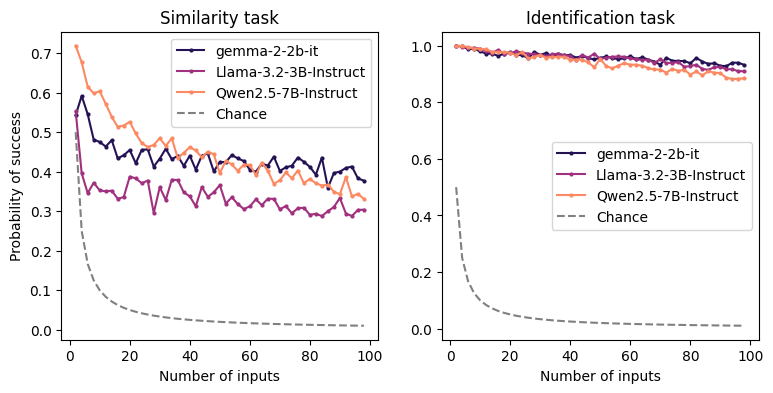

In [18]:
f,axs = plt.subplots(1,2,figsize=(9, 4))
seq_lens = np.array(seq_lens)
for m in model_names:
    col = plt.cm.magma(0.15) if m == "gemma-2-2b-it" else plt.cm.magma(0.45) if m == "Llama-3.2-3B-Instruct" else plt.cm.magma(0.75)
    axs[0].plot(seq_lens,performances_sim[m],'-o', label=m, markersize = 2, color = col)
    axs[1].plot(seq_lens,performances_id[m],'-o', label=m, markersize=2, color = col)

axs[0].plot(seq_lens,1/(seq_lens),'--',color='gray', label ="Chance")
axs[1].plot(seq_lens,1/(seq_lens),'--',color='gray', label ="Chance")
axs[0].set_title("Similarity task")
axs[0].legend()
axs[0].set_xlabel("Number of inputs")
axs[0].set_ylabel("Probability of success")
axs[1].set_title("Identification task")
axs[1].legend()
axs[1].set_xlabel("Number of inputs")
# Save figure
save_plot_path = "/home/mnurisso/miller_npl/llm/plots"

plt.savefig(save_plot_path+f"/experiment_years_performances.pdf", bbox_inches='tight')


## Evidence of resolution experiment

In [ ]:
names = np.array([
    "Alice", "Bob", "Charlie", "David", "Eve", "Frank", "Grace", "Heidi",
    "Ivan", "Judy", "Karl", "Liam", "Mallory", "Nina", "Oscar", "Peggy",
    "Quentin", "Rupert", "Sybil", "Trent", "Uma", "Victor", "Walter",
    "Xander", "Yvonne", "Zach", "Abigail", "Benjamin", "Catherine", "Daniel",
    "Elena", "Frederick", "Gabriella", "Henry", "Isabella", "Jack", "Katherine",
    "Lucas", "Mia", "Nathan", "Olivia"
])

Run the experiment and save the probability of the model picking the lowest year

In [ ]:
ncenters = 40
nrep = 20

performances = {}

for nn in range(ncenters):
    print(f"Repetition {nn}")
    center = np.random.randint(1500,1700)
    pspace = np.arange(center-300,center+300,5)
    ages_list = [[center-d,center+d] for d in [2,5,20,50,100,200]]
    performances[center] = []
    for k,ages in enumerate(ages_list):
        performance = np.zeros(len(pspace))
        counts = np.zeros(len(pspace))

        for j,probe in tqdm(enumerate(pspace)):
            corrects = []
            sentences = []
            sampled_names = []
            orders_0 = []
            for n in range(nrep):
                # Randomize the names
                sampled_names.append(names[np.argsort(np.random.rand(len(names)))[:2]])
                # Randomize the order of the ages 
                order = [0,1] if np.random.rand() < 0.5 else [1,0]
                orders_0.append(0 if order == [0,1] else 1)
                sentences.append(f"{sampled_names[-1][0]} was born in {(ages[order[0]])}. {sampled_names[-1][1]} was born in {(ages[order[1]])}. Who was born closest to {(probe)}?"+" Answer with a single name. ")
                corrects.append(str(sampled_names[-1][np.argmin([np.abs(ages[order[i]] - probe) for i in range(2)])]))
            outputs = pipe(sentences)
            for n in range(nrep):
                output_str = outputs[n]
                answer = [p for p in sampled_names[n] if p in output_str]
                if len(answer) == 0:
                    answer = "NULL"
                else:
                    answer = str(answer[0])
                if answer in sampled_names[n]:
                    if answer == sampled_names[n][orders_0[n]]:
                        performance[j] += 1
                    counts[j] += 1
       
        performances[center].append(performance/counts)

#### Save results

In [ ]:
save_path = "YOUR_SAVE_PATH"

In [ ]:
import pickle

with open(save_path+f"/experiment_resolution_years_{model_name}_small.pkl", "wb") as f:
    save_dict = {"ages_list":ages_list, "performances":performances, "pspace":pspace, "nrep":nrep}
    pickle.dump(save_dict, f)

#### Load saved results

In [ ]:
import pickle


model_name = "gemma-2-2b-it"
#model_name = "Llama-3.2-3B-Instruct"
#model_name = "Qwen2.5-7B-Instruct"

# Load the pickle file
with open(save_path+f"/experiment_resolution_years_{model_name}_small.pkl", "rb") as f:
    save_dict = pickle.load(f)

# Print or inspect the loaded data
pspace = save_dict["pspace"]
performances = save_dict["performances"]
nrep = save_dict["nrep"]
ages_list = save_dict["ages_list"]

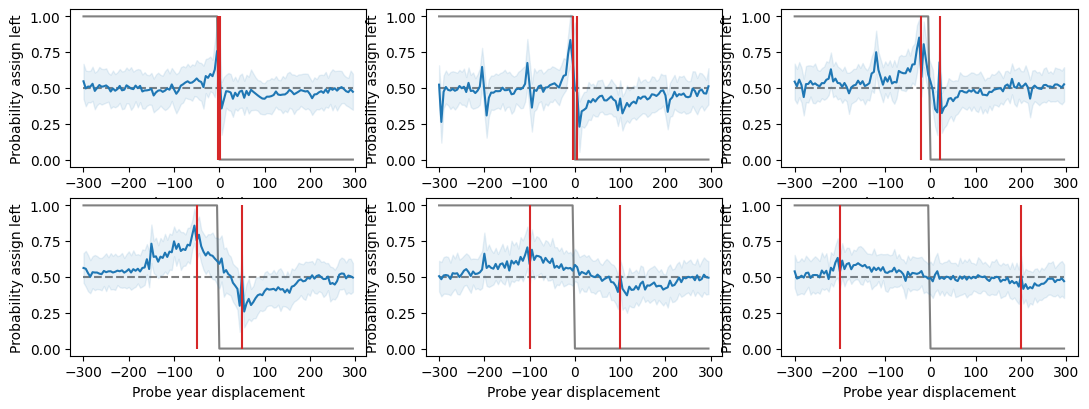

In [ ]:
Delta=[2,5,20,50,100,200]
all_res = np.array([performances[k] for k in performances.keys()])
pspace = np.arange(-300,+300,5)
mean_res = np.mean(all_res,0)
std_res= np.std(all_res,0)
f = plt.figure(figsize = (13,4.5))
for i in range(len(Delta)):
    ax = plt.subplot(2,3,i+1)
    plt.plot(pspace,mean_res[i,:], color = "tab:blue")
    plt.fill_between(pspace,mean_res[i,:]-std_res[i,:], mean_res[i,:]+std_res[i,:], alpha = 0.1, color = "tab:blue")
    #ax.plot(pspace,all_res[0,i,:])
    ax.vlines([-Delta[i],Delta[i]],0,1,"tab:red")
    ax.hlines(0.5,min(pspace),max(pspace),"gray","--",zorder=-1)
    ax.set_ylim([-0.05,1.05])
    ax.plot(pspace, pspace < 0, color = "grey", zorder = -1)
    ax.set_xlabel("Probe year displacement")
    ax.set_ylabel("Probability assign left")

### Figure 5b

/tmp/ipykernel_1387604/1136138363.py:12: RuntimeWarning: divide by zero encountered in divide
  g1 = 1/(alpha*np.abs(pspace + d))
/tmp/ipykernel_1387604/1136138363.py:13: RuntimeWarning: divide by zero encountered in divide
  g2 = 1/(alpha*np.abs(pspace - d))
/tmp/ipykernel_1387604/1136138363.py:14: RuntimeWarning: invalid value encountered in divide
  axs[0,i-2].plot(pspace,g1/(g1+g2)*(pspace<0) + g2/(g1+g2)*(pspace>=0), color = plt.cm.magma(0.1))


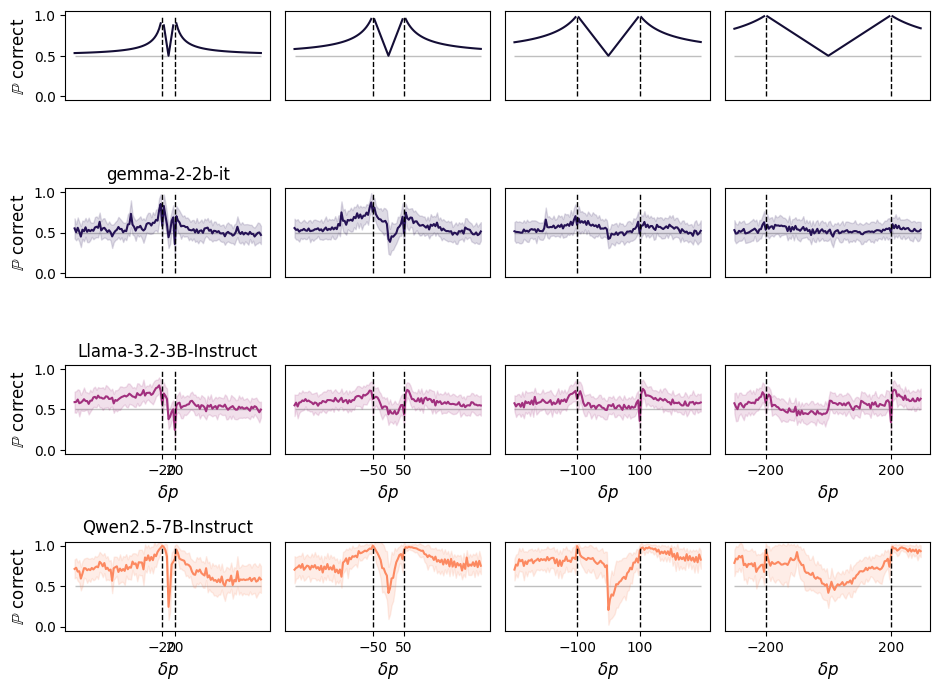

In [7]:
def pro(all_res):
    return all_res*(pspace<0) + (1-all_res)*(pspace>=0)

Delta= [2,5,20,50,100,200]

f,axs = plt.subplots(4,4,figsize = (9.5,7))
m = 0.4
alpha = 0.006
for i,d in enumerate(Delta):
    if i >= 2:

        g1 = 1/(alpha*np.abs(pspace + d))
        g2 = 1/(alpha*np.abs(pspace - d))
        axs[0,i-2].plot(pspace,g1/(g1+g2)*(pspace<0) + g2/(g1+g2)*(pspace>=0), color = plt.cm.magma(0.1))
    
        axs[0,i-2].vlines([-d,d],0,1,"k",'--',linewidth=1)
        axs[0,i-2].hlines(0.5,min(pspace),max(pspace),"gray",linewidth = 1,alpha=0.5,zorder=-100)
        axs[0,i-2].set_ylim([-0.05,1.05])

        axs[0,i-2].set_xticks([])
        if i == 2:
            axs[0,i-2].set_ylabel("$\mathbb{P}$ correct", fontsize=12)
        if i != 2:
            axs[0,i-2].set_yticks([])


model_name = "gemma-2-2b-it"
with open(save_path+f"/experiment_resolution_years_{model_name}_small.pkl", "rb") as f:
    save_dict = pickle.load(f)
pspace = save_dict["pspace"]
performances = save_dict["performances"]
all_res = np.array([performances[k] for k in performances.keys()])
all_res = pro(all_res)
pspace = np.arange(-300,+300,5)
mean_res = np.mean(all_res,0)
std_res= np.std(all_res,0)

for i,d in enumerate(Delta):
    if i >= 2:
        axs[1,i-2].plot(pspace,mean_res[i,:], color = plt.cm.magma(0.15))
        axs[1,i-2].fill_between(pspace,mean_res[i,:]-std_res[i,:], mean_res[i,:]+std_res[i,:], alpha = 0.15, color = plt.cm.magma(0.15))
        #ax.plot(pspace,all_res[0,i,:])
        axs[1,i-2].vlines([-d,d],0,1,"k",'--',linewidth=1)
        axs[1,i-2].hlines(0.5,min(pspace),max(pspace),"gray",linewidth = 1,alpha=0.5,zorder=-100)
        axs[1,i-2].set_ylim([-0.05,1.05])

        axs[1,i-2].set_xticks([])
        if i == 2:
            axs[1,i-2].set_ylabel("$\mathbb{P}$ correct", fontsize=12)
        if i != 2:
            axs[1,i-2].set_yticks([])
axs[1,0].set_title(model_name)

model_name = "Llama-3.2-3B-Instruct"

with open(save_path+f"/experiment_resolution_years_{model_name}_small.pkl", "rb") as f:
    save_dict = pickle.load(f)
pspace = save_dict["pspace"]
performances = save_dict["performances"]
all_res = np.array([performances[k] for k in performances.keys()])
all_res = pro(all_res)

pspace = np.arange(-300,+300,5)
mean_res = np.mean(all_res,0)
std_res= np.std(all_res,0)

for i,d in enumerate(Delta):
    if i >= 2:
        axs[2,i-2].plot(pspace,mean_res[i,:], color = plt.cm.magma(0.45))
        axs[2,i-2].fill_between(pspace,mean_res[i,:]-std_res[i,:], mean_res[i,:]+std_res[i,:], alpha = 0.15, color = plt.cm.magma(0.45))
        axs[2,i-2].vlines([-d,d],0,1,"k",'--',linewidth=1)
        axs[2,i-2].hlines(0.5,min(pspace),max(pspace),"gray",linewidth = 1,alpha=0.5,zorder=-100)
        axs[2,i-2].set_ylim([-0.05,1.05])
        axs[2,i-2].set_xlabel("$\delta p$", fontsize=12)
        axs[2,i-2].set_xticks([-d,d])
        if i == 2:
            axs[2,i-2].set_ylabel("$\mathbb{P}$ correct",fontsize=12)
        if i != 2:
            axs[2,i-2].set_yticks([])
axs[2,0].set_title(model_name)


model_name = "Qwen2.5-7B-Instruct"

with open(save_path+f"/experiment_resolution_years_{model_name}_small.pkl", "rb") as f:
    save_dict = pickle.load(f)
pspace = save_dict["pspace"]
performances = save_dict["performances"]
all_res = np.array([performances[k] for k in performances.keys()])
all_res = pro(all_res)

pspace = np.arange(-300,+300,5)
mean_res = np.mean(all_res,0)
std_res= np.std(all_res,0)

for i,d in enumerate(Delta):
    if i >= 2:
        axs[3,i-2].plot(pspace,mean_res[i,:], color = plt.cm.magma(0.75))
        axs[3,i-2].fill_between(pspace,mean_res[i,:]-std_res[i,:], mean_res[i,:]+std_res[i,:], alpha = 0.15, color = plt.cm.magma(0.75))
        axs[3,i-2].vlines([-d,d],0,1,"k",'--',linewidth=1)
        axs[3,i-2].hlines(0.5,min(pspace),max(pspace),"gray",linewidth = 1,alpha=0.5,zorder=-100)
        axs[3,i-2].set_ylim([-0.05,1.05])
        #ax.plot(pspace, pspace < 0, color = "grey", zorder = -1)
        axs[3,i-2].set_xlabel("$\delta p$", fontsize=12)
        axs[3,i-2].set_xticks([-d,d])
        if i == 2:
            axs[3,i-2].set_ylabel("$\mathbb{P}$ correct",fontsize=12)
        if i != 2:
            axs[3,i-2].set_yticks([])
axs[3,0].set_title(model_name)

plt.tight_layout()
